# Personal Project: Exploratory Data Analysis (EDA) on Telco Data Set

## What is EDA and Why Do We Do It? ##
Exploratory Data Analysis (EDA) is the process of **visually and statistically examining a dataset before building any models**. It helps us:
* Understand the structure, shape, and quality of the data
* Identify missing values, outliers, and data type issues
* Discover patterns and relationships between features and the target variable
* Make informed decisions about preprocessing and feature engineering.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style = 'whitegrid', palette = 'muted')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titlesize'] = 14

print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


## Load Dataset

In [5]:
df = pd.read_csv('/Users/chldbng/Documents/projects/customer-churn-predictor/data/raw/telco-customer-churn.csv')

print(f'✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Inspection

In [6]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Missing Values and Fix Data Types

In [10]:
print('=== Standard NaN Missing Values ===')
print(df.isnull().sum())

print('\n === Hidden Emtpy Strings ===')
for col in df.select_dtypes(include = 'str').columns:
    empty_count = (df[col].str.strip() == ' ').sum()
    if empty_count > 0:
        print(f'{col}: {empty_count} empty strings found')

df['TotalCharges'] = df['TotalCharges'].str.strip()
df['TotalCharges'] = df['TotalCharges'].replace('', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

df['TotalCharges'].fillna(0, inplace = True)

print('\n ✅ TotalCharges cleaned. Remaining nulls:' , df['TotalCharges'].isnull().sum())

=== Standard NaN Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

 === Hidden Emtpy Strings ===

 ✅ TotalCharges cleaned. Remaining nulls: 11


## Target Variable (Churn Distribution)

In [12]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize = True) * 100

print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


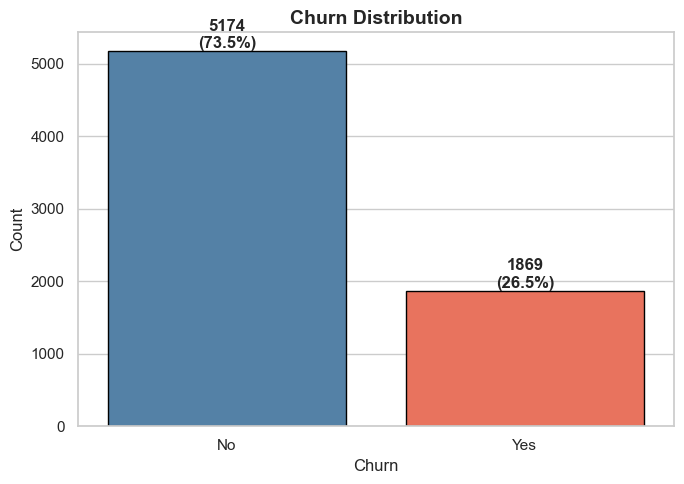

In [17]:
plt.figure(figsize = (7, 5))

ax = sns.countplot(data = df, x = 'Churn', palette = ['steelblue', 'tomato'],
                   edgecolor = 'black')

for p in ax.patches:
    count = int(p.get_height())
    pct = count / len(df) * 100
    ax.annotate(f'{count}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2, p.get_height()), ha = 'center', va = 'bottom', fontsize=12, fontweight = 'bold')

plt.title('Churn Distribution', fontsize = 14, fontweight = 'bold')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Numerical Features Analysis

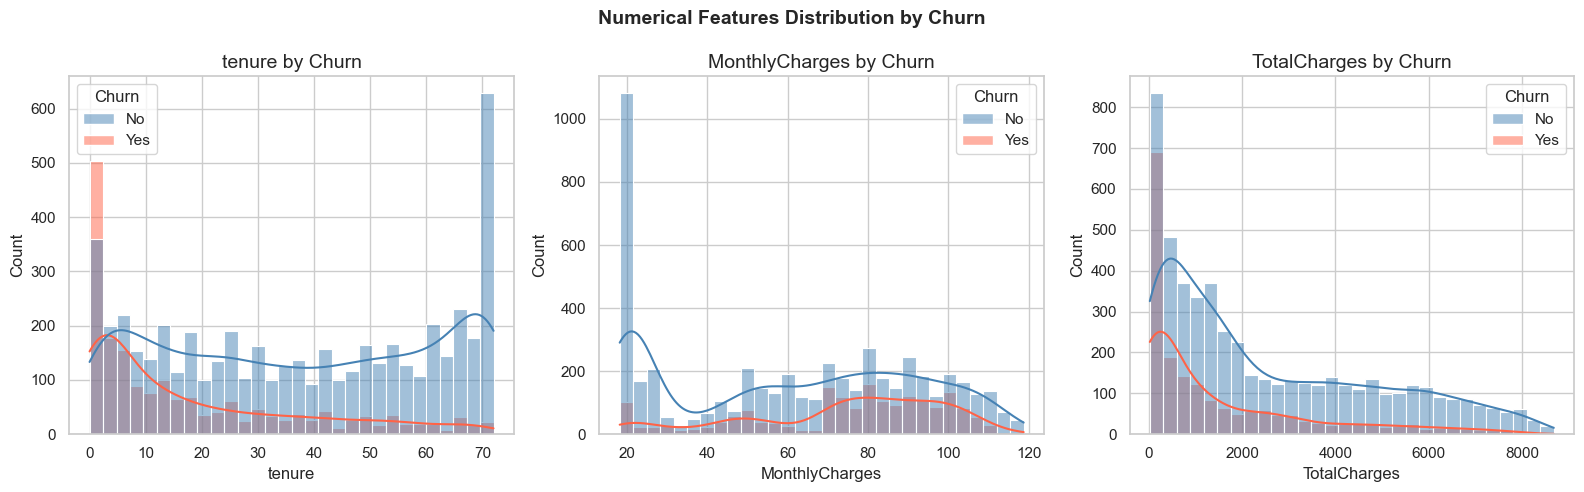

In [20]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize = (16,5))

for i, col in enumerate(num_cols):
    sns.histplot(df, x = col, hue = 'Churn', bins = 30, kde = True, ax = axes[i], palette = ['steelblue', 'tomato'])
    axes[i].set_title(f'{col} by Churn')

plt.suptitle('Numerical Features Distribution by Churn',fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/numerical_distributions.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Categorical Features Analysis

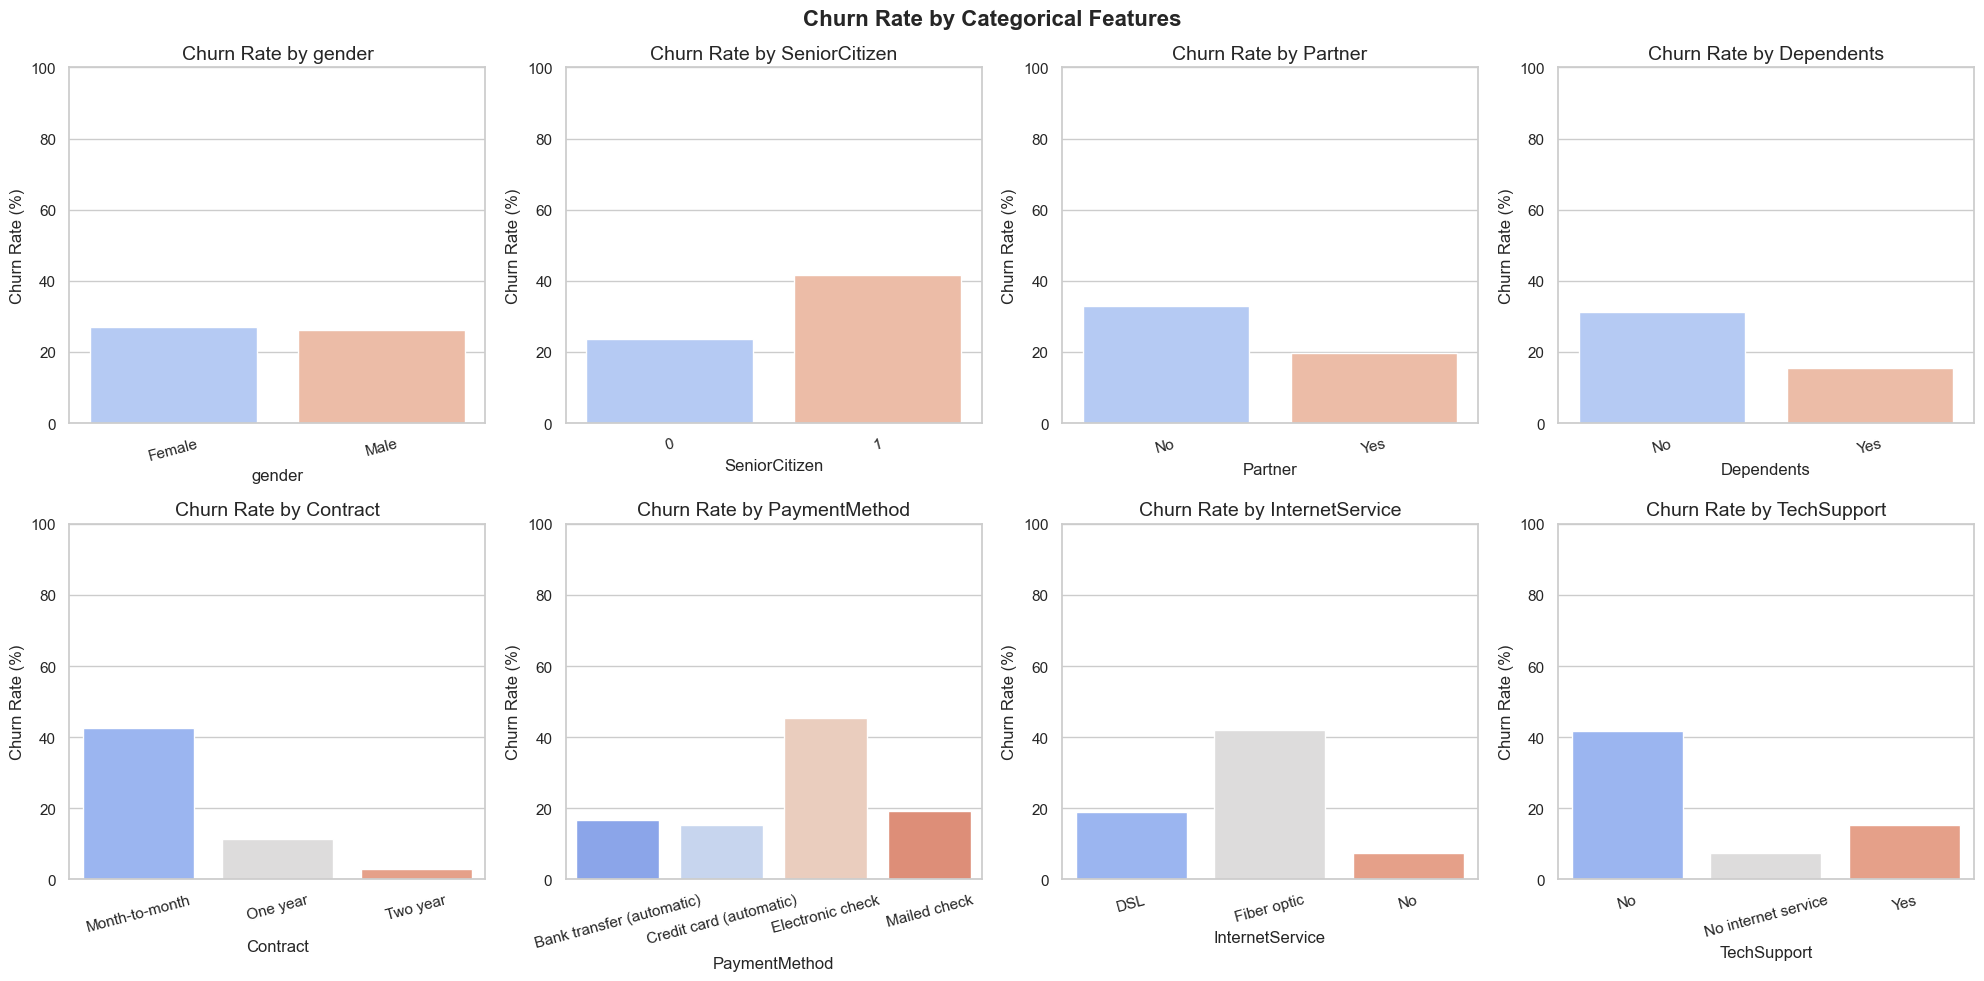

In [24]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'Contract', 'PaymentMethod', 'InternetService', 'TechSupport']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']

    sns.barplot(churn_rate, x = col, y = 'Churn Rate (%)',
                ax = axes[i], palette = 'coolwarm')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].tick_params(axis = 'x', rotation = 15)
    axes[i].set_ylim(0, 100)

plt.suptitle('Churn Rate by Categorical Features', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/categorical_churn_rates.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Correlation Analysis

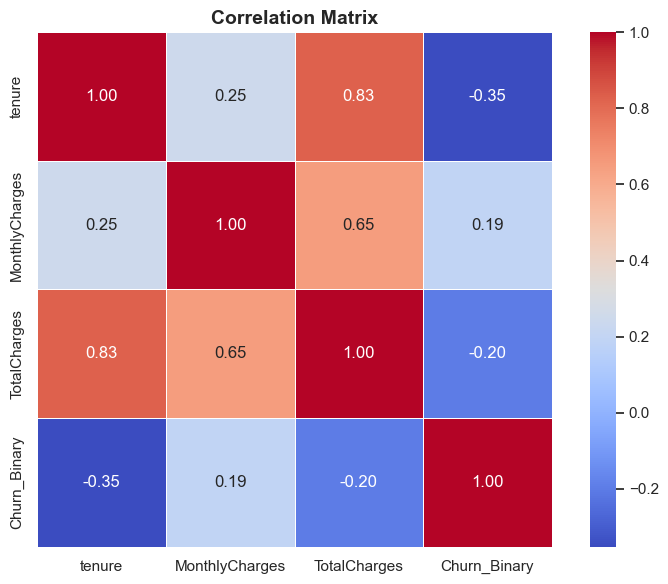

In [26]:
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm',
            square = True, linewidths = 0.5)
plt.title('Correlation Matrix', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [27]:
print('Correlation with Churn:')
print(df[corr_cols].corr()['Churn_Binary'].sort_values(ascending = False))

Correlation with Churn:
Churn_Binary      1.000000
MonthlyCharges    0.193356
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_Binary, dtype: float64


## 📋 Key Findings

1. **Class Imbalance** - ~26% churned vs ~74% retained.
2. **Tenure** - Shorter tenure correlates with higher churn. Long-term customers are more loyal.
3. **Monthly Charges** - Churned customers tend to have higher monthly charges.
4. **Contract Types** - Month-to-Month contracts have the highest churn rate.
5. **Internet Service** - Fiber optic customers churn more than DSL customers.
6. **Tech Support** - Customers without tech support churn at higher rates.